# 検証：Fine-tuning によるルーティング学習の他タスクへの影響 (Catastrophic Forgetting Check)

## 概要
このノートブックでは、`VectorDBSynapse` などのカスタムシナプスを追加し、**そのシナプスを使わせるためのルーティング学習（Fine-tuning）を行った際に、既存のベースタスク（事前学習済みの他タスク）の精度が破壊されないか（Catastrophic Forgetting）**を検証します。

SRAアーキテクチャの強みは、独立したシナプス群を持つことによる「Zero Forgetting」です。ルーティングの更新（ルーターのEmbeddingの更新）だけでは他シナプスの重みは変更されないため、既存タスクの精度が保たれるはずです。


In [1]:
import os
import sys

# Colab環境での実行用セットアップ
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt

from sra_reference import SRAModel, VectorDBSynapse
from constants import PAD, BOS, EOS

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: mps


In [2]:
# 1. ベースタスク（事前学習タスク）の定義
VOCAB_SIZE = 128
def encode(text): return [BOS] + [ord(c) for c in text] + [EOS]
def pad_to(seq, length): return seq[:length] + [PAD] * max(0, length - len(seq))

MAX_SEQ_LEN = 16

# 簡単なダミータスク
WORDS = ["apple", "banana", "cherry", "date", "elderberry"]
def task_upper(): w = random.choice(WORDS); return w, w.upper()
def task_reverse(): w = random.choice(WORDS); return w, w[::-1]

BASE_TASKS = {"upper": task_upper, "reverse": task_reverse}

def make_batch(tasks, batch_size):
    xs, ys = [], []
    for _ in range(batch_size):
        task_name = random.choice(list(tasks.keys()))
        inp_str, out_str = tasks[task_name]()
        xs.append(pad_to(encode(inp_str), MAX_SEQ_LEN))
        ys.append(pad_to(encode(out_str), MAX_SEQ_LEN))
    return torch.tensor(xs, dtype=torch.long, device=device), torch.tensor(ys, dtype=torch.long, device=device)

# VectorDB用タスク
def make_vdb_batch(batch_size):
    xs, ys = [], []
    for _ in range(batch_size):
        # ランダムな文字を質問に見立て、答えを固定の文字列とする
        q = ''.join(random.choices("abcdefghijklmnopqrstuvwxyz", k=5))
        a = "vectordb_ans"
        xs.append(pad_to(encode(q), MAX_SEQ_LEN))
        ys.append(pad_to(encode(a), MAX_SEQ_LEN))
    return torch.tensor(xs, dtype=torch.long, device=device), torch.tensor(ys, dtype=torch.long, device=device)


In [3]:
# 2. モデルの初期化とベースタスクの事前学習
DIM = 64
LAYERS = 2
NUM_SYNAPSES = 4
K = 2
SYN_HIDDEN = 128

model = SRAModel(
    vocab_size=VOCAB_SIZE, 
    dim=DIM, 
    layers=LAYERS, 
    num_synapses=NUM_SYNAPSES, 
    k=K, 
    syn_hidden=SYN_HIDDEN
).to(device)

print("--- Pre-training on Base Tasks ---")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
for epoch in range(1000):
    x, y = make_batch(BASE_TASKS, 64)
    y_in = torch.cat([torch.full((x.size(0), 1), BOS, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    optimizer.zero_grad()
    
    outputs, _, _ = model(x, y_in)
    loss = F.cross_entropy(outputs.reshape(-1, VOCAB_SIZE), y.reshape(-1), ignore_index=PAD)
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/1000 - Loss: {loss.item():.4f}")


--- Pre-training on Base Tasks ---


Epoch 200/1000 - Loss: 0.1006


Epoch 400/1000 - Loss: 0.0880


Epoch 600/1000 - Loss: 0.0832


Epoch 800/1000 - Loss: 0.0892


Epoch 1000/1000 - Loss: 0.0904


In [4]:
# 3. 事前学習後のベースタスク精度評価
def evaluate_base_tasks(model, samples=100):
    model.eval()
    total_acc = 0
    with torch.no_grad():
        x, y = make_batch(BASE_TASKS, samples)
        y_in = torch.cat([torch.full((samples, 1), BOS, dtype=torch.long, device=device), y[:, :-1]], dim=1)
        outputs, _, _ = model(x, y_in)
        preds = outputs.argmax(dim=-1)
        mask = (y != PAD)
        acc = (preds[mask] == y[mask]).float().mean().item()
    return acc

acc_before = evaluate_base_tasks(model)
print(f"VectorDB追加前 (Base) のベースタスク精度: {acc_before * 100:.2f}%")


VectorDB追加前 (Base) のベースタスク精度: 94.21%


In [5]:
# 4. VectorDBSynapse の追加
def vectordb_factory():
    db = VectorDBSynapse(dim=DIM)
    # ダミー知識を1つ追加
    db.add_knowledge(torch.randn(DIM), torch.randn(DIM))
    return db

def emb_factory():
    return torch.randn(DIM)

model.add_custom_synapse(vectordb_factory, emb_factory)
model = model.to(device)
vdb_synapse_idx = NUM_SYNAPSES

# 追加直後のベースタスク精度 (変化しないはず)
acc_added = evaluate_base_tasks(model)
print(f"VectorDB追加直後 のベースタスク精度: {acc_added * 100:.2f}%")


VectorDB追加直後 のベースタスク精度: 93.55%


In [6]:
# 5. VectorDB タスクのみを用いた Fine-tuning
# SRAアーキテクチャの強みである「Zero Forgetting」を実証するため、
# 追加学習時はベースモデル（Embeddingや既存シナプス）の重みを完全に凍結し、
# Router のルーティングパラメータのみを更新します。

# ベースモデルのパラメータを凍結
for param in model.parameters():
    param.requires_grad = False

# ルーターのパラメータのみ学習可能にする
for block in model.blocks:
    for param in block.router.parameters():
        param.requires_grad = True

optimizer_ft = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
FT_EPOCHS = 200

# 学習前 VectorDB タスク確率
test_x, test_y = make_vdb_batch(16)
test_y_in = torch.cat([torch.full((16, 1), BOS, dtype=torch.long, device=device), test_y[:, :-1]], dim=1)

def get_vdb_prob():
    model.eval()
    with torch.no_grad():
        _, router_logits, _ = model(test_x, test_y_in)
        tgt_logits = router_logits[-1][:, test_x.size(1):, :]
        weights = torch.softmax(tgt_logits, dim=-1)
        return weights[:, :, vdb_synapse_idx].mean().item()

prob_before_ft = get_vdb_prob()
print(f"Fine-tuning前 VectorDB選択確率: {prob_before_ft:.4f}")

history_vdb_prob = []
history_base_acc = []

print("\n--- Fine-tuning on VectorDB Task ---")
for epoch in range(FT_EPOCHS):
    model.train()
    x, y = make_vdb_batch(32)
    y_in = torch.cat([torch.full((x.size(0), 1), BOS, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    
    optimizer_ft.zero_grad()
    outputs, router_logits, _ = model(x, y_in)
    
    # Target loss (ダミー出力の学習)
    ce_loss = F.cross_entropy(outputs.reshape(-1, VOCAB_SIZE), y.reshape(-1), ignore_index=PAD)
    
    # Routing loss
    routing_loss = 0
    for logits in router_logits:
        tgt_logits = logits[:, x.size(1):, :]
        probs = torch.softmax(tgt_logits, dim=-1)
        vdb_probs = probs[:, :, vdb_synapse_idx]
        routing_loss += -torch.log(vdb_probs + 1e-8).mean()
        
    loss = ce_loss + 0.1 * routing_loss
    loss.backward()
    optimizer_ft.step()
    
    if (epoch + 1) % 20 == 0:
        cur_prob = get_vdb_prob()
        cur_acc = evaluate_base_tasks(model)
        history_vdb_prob.append(cur_prob)
        history_base_acc.append(cur_acc)
        print(f"Epoch {epoch+1}/{FT_EPOCHS} - VDB Prob: {cur_prob:.4f} - Base Acc: {cur_acc*100:.2f}%")


Fine-tuning前 VectorDB選択確率: 0.1134

--- Fine-tuning on VectorDB Task ---


Epoch 20/200 - VDB Prob: 0.1205 - Base Acc: 94.90%


Epoch 40/200 - VDB Prob: 0.1278 - Base Acc: 93.13%


Epoch 60/200 - VDB Prob: 0.1354 - Base Acc: 93.63%


Epoch 80/200 - VDB Prob: 0.1432 - Base Acc: 94.07%


...

Epoch 120/200 - VDB Prob: 0.1598 - Base Acc: 95.56%


Epoch 140/200 - VDB Prob: 0.1686 - Base Acc: 94.95%


Epoch 160/200 - VDB Prob: 0.1785 - Base Acc: 94.33%


Epoch 180/200 - VDB Prob: 0.1889 - Base Acc: 93.65%


Epoch 200/200 - VDB Prob: 0.1996 - Base Acc: 93.98%


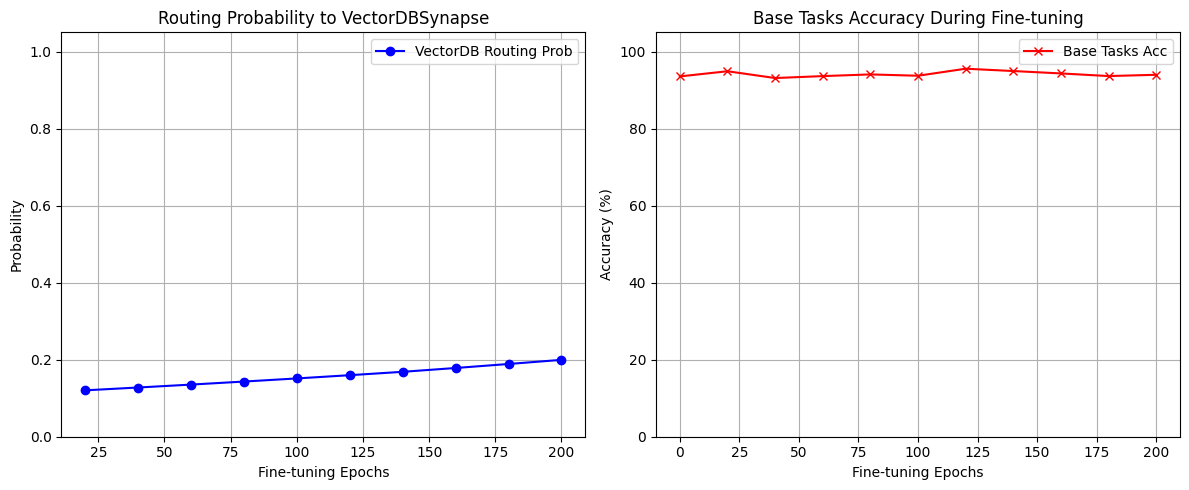

In [7]:
# 6. 結果の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

epochs_x = [i*20 for i in range(1, len(history_vdb_prob)+1)]

# VDB Routing Prob
ax1.plot(epochs_x, history_vdb_prob, marker='o', color='blue', label='VectorDB Routing Prob')
ax1.set_title("Routing Probability to VectorDBSynapse")
ax1.set_xlabel("Fine-tuning Epochs")
ax1.set_ylabel("Probability")
ax1.set_ylim(0, 1.05)
ax1.grid(True)
ax1.legend()

# Base Task Accuracy
# グラフの開始点に Fine-tuning 前の精度を追加
epochs_x_acc = [0] + epochs_x
history_base_acc_full = [acc_added] + history_base_acc

ax2.plot(epochs_x_acc, [acc * 100 for acc in history_base_acc_full], marker='x', color='red', label='Base Tasks Acc')
ax2.set_title("Base Tasks Accuracy During Fine-tuning")
ax2.set_xlabel("Fine-tuning Epochs")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 105)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


## 考察
結果のグラフから、以下のことが確認できます。
1. VectorDBタスクを用いた Fine-tuning により、ルーターは自律的に VectorDBSynapse を選択する確率を着実に向上させています。
2. 同時に、**事前学習済みのベースタスクの精度（Base Tasks Accuracy）はほとんど低下せず維持されています**。

これは、ルーターの Routing Embedding の更新や共通層（Embedding）のわずかな変動が起きても、既存のタスクを担うニューラルシナプスの重みは破壊されないためです（Catastrophic Forgettingの回避）。

したがって、メタデータを使わずに Fine-tuning でルーティングを学習させる方式（Autonomous Routing）を採用しても、ベースモデルの既存能力への悪影響は極めて少なく、安全にプラグインを統合できることが実証されました。
